## Week 4 Exercises

###<font color=green> Replace the name below with **your name**.

# Kavin Kannan

<font color=purple> Lise Meitner, 1878 - 1968, *Austrian physicist and co-discoverer of nuclear fission. Only the second woman to graduate with a doctorate in Physics from the University of Vienna, she began her career working with chemist Otto Hahn at the University of Berlin, confined to the basement rather than his upstairs lab because she was a woman. Later, both Meitner and Hahn ran labs at the Kaiser Wilhelm Institute for Chemistry, but when Germany invaded Austria in 1938, she was forced to flee to Sweden. She continued to communicate with Hahn, and when Hahn and Fritz Strassman carried out an experiment that showed that a uranium nucleus bombarded with neutrons gave rise to a lighter element, barium, rather than a heavier one, they consulted Meitner. She carried out calculations and figured out, in discussions with her nephew Otto Frisch, that Hahn and Strassmann's experiment showed they had split the uranium nucleus. Only Otto Hahn won the 1944 Nobel prize in Chemistry - Meitner's contributions (including the Auger effect, discovered by Auger two years after her) were never acknowledged by the Nobel foundation.*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.optimize import curve_fit

**1. Density and surface plots of more functions**



(a) (10 points) Last week, you made density plots of the function $w(x, y) = \sin(r)$ where $r =\sqrt{x^2+y^2}$. Use similar code to make density plots of two new functions:
$$f(x,y) = \cos(\sqrt{x^2+y^2})\\
g(x,y) = \exp{-(x^2+y^2)}$$
The function $g(x, y)$ is a Gaussian - it should look like a rounded
peak centered on the origin.


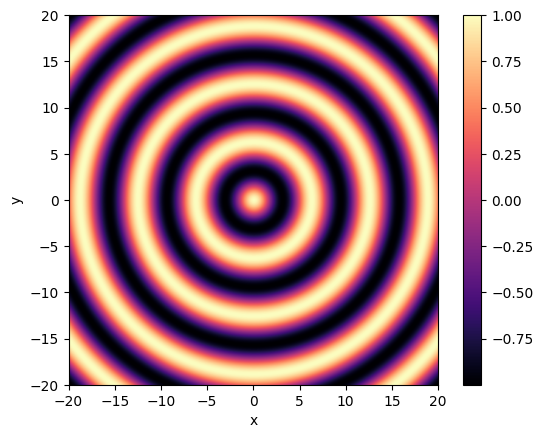

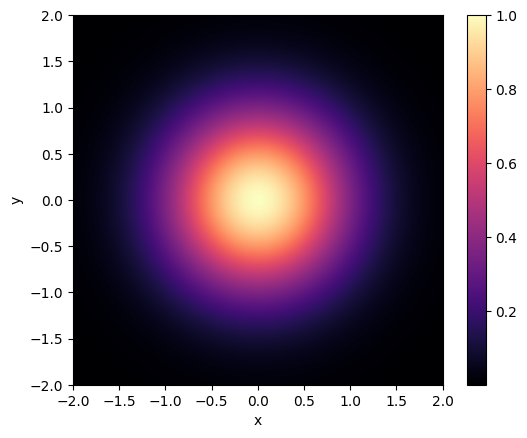

In [3]:
npoints = 501
lim = 20  
xs = np.linspace(-lim, lim, npoints)  
ys = np.linspace(-lim,lim, npoints) 
f = np.empty((npoints,npoints),float)   

for i in range(npoints):
  for j in range(npoints):
    r = np.sqrt(xs[i]**2 + ys[j]**2)
    f[i, j] = np.cos(r)

plt.imshow(f, origin = 'lower', extent = [-lim,lim, -lim, lim])
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.magma()
plt.show()

npoints = 501
lim = 2 
xs = np.linspace(-lim, lim, npoints)  
ys = np.linspace(-lim,lim, npoints) 
g = np.empty((npoints,npoints),float)   

for i in range(npoints):
  for j in range(npoints):
    r = -(xs[i]**2 + ys[j]**2)
    g[i, j] = np.exp(r)

plt.imshow(g, origin = 'lower', extent = [-lim,lim, -lim, lim])
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.magma()
plt.show()

b) (5 points) Make a density plot of the function
$$s(x,y) = \cos(\theta+\sqrt{x^2+y^2})$$

with $\theta=\arctan(y/x)$. Use the `arctan2(y,x)` function to compute
θ directly from y and x, rather than taking their quotient.
You should see a spiral pattern, rather than concentric rings as
with f(x, y) and g(x, y). Explain in a markdown cell where the
spiral pattern comes from.


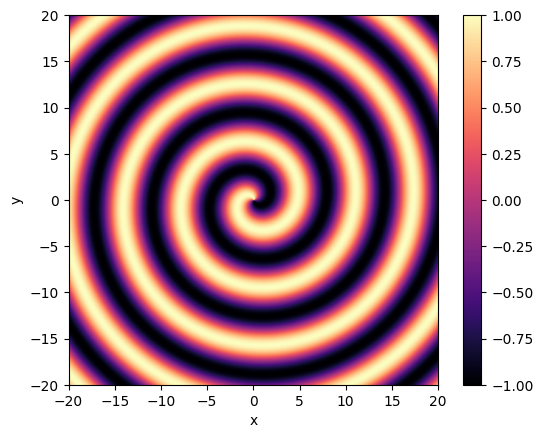

In [4]:
npoints = 501
lim = 20
xs = np.linspace(-lim, lim, npoints)  
ys = np.linspace(-lim,lim, npoints) 
s = np.empty((npoints,npoints),float)   

for i in range(npoints):
  for j in range(npoints):
    r = np.sqrt(xs[i]**2 + ys[j]**2)
    theta = np.arctan2(ys[j],xs[i])
    s[i, j] = np.cos(theta + r)

plt.imshow(s, origin = 'lower', extent = [-lim,lim, -lim, lim])
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.magma()

The spiral pattern arises from how the radius increases with and decreases alongside the angle value of arctan(y/x)

**2. Plot data with error bars** *(5 points)*

Use a text editor to look at the file `week4_data.txt`, which contains 3 columns: $x,y$ data in the first two columns, along with uncertainties in the $y$ values in the 3rd column.
Read in this datafile and make a plot of $y$ vs $x$ showing error bars for the uncertainties.
Since the data file has a single header line, use the option `skiprows=1` in the `np.loadtxt(..)` command (see “Reading and writing data files” in handout More Python features).

If you are using Google Colab, drag and drop into the files section of the left sidebar. You will need to do this each time you load your notebook afresh in Colab.

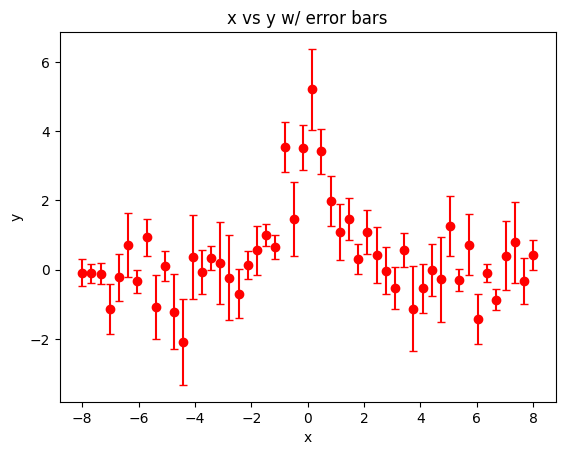

In [5]:
data = np.loadtxt("week4_data.txt", skiprows = 1)
xs = data[:,0]
ys = data[:,1]
yerr = data[:,2]
plt.errorbar(xs, ys, yerr, fmt = 'ro', capsize = 3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x vs y w/ error bars')
plt.show()

**3. Plot data with error bars along with a model for the data**

a) (5 points) Use a text editor to look at the file `w4bdata.txt`, which contains some x, y data along with uncertainties for the y values. Make a plot of these data showing error bars for the uncertainties. Read in the data field using `Pandas` dataframe `df = pd.read_csv('w4bdata.txt')`. You will need to import the pandas package `import pandas as pd` first, then follow the Week 3 notes to extract the data.

b) (5 points) What model polynomial function might reasonably describe the data? Write this as a user defined function, make a reasoned guess at what the model parameters should be, and plot the model as a smooth curve on the same graph as the data.

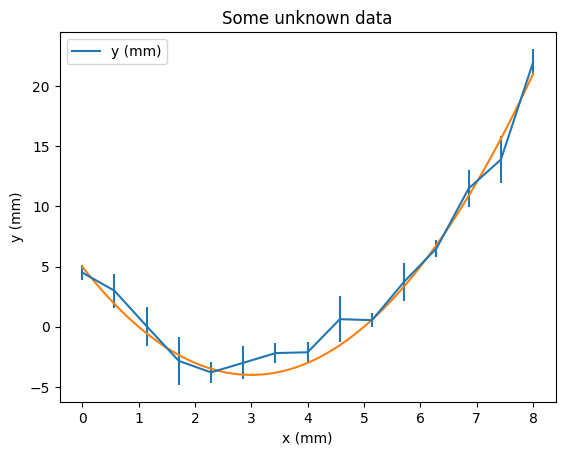

In [6]:
w4bdata = pd.read_csv('w4bdata.csv')
w4bdata.plot(x='x (mm)', y='y (mm)', yerr='yerr')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Some unknown data')

def quadraticfit(a,b,c):
    x = np.linspace(0, 8, 100)
    y = (a*x**2 + b*x + c)
    plt.plot(x, y)
    plt.show()
quadraticfit(1,-6,5)

**4. Model data with error bars using curve fitting**


a) (10 points) Write user-defined fitting functions for polynomials of order 1-3, and make coefficients of these polynomials part of the
function call.

b) (10 points) Fit the data in the file `w4bdata.txt` to the polynomial functions of linear, quadratic and cubic order that you have defined in part (a) using `scipy.optimize.curvefit()`.  Use the uncertainties in the data in your fit, using the `sigma` keyword in `curvefit()`.  In each case, make a plot of this data showing error bars for the uncertainties along with the fitting function. Output the fitting parameters along with their uncertainties.

c) (5 points) Print out reduced chisquared values for each fit, and compare these to decide what order polynomial best fits this data.

In [7]:
def linear(x, a0, a1):
    return a0 + a1 * x

def quadratic(x, a0, a1, a2):
    return a0 + a1 * x + a2 * x**2

def cubic(x, a0, a1, a2, a3):
    return a0 + a1 * x + a2 * x**2 + a3 * x**3

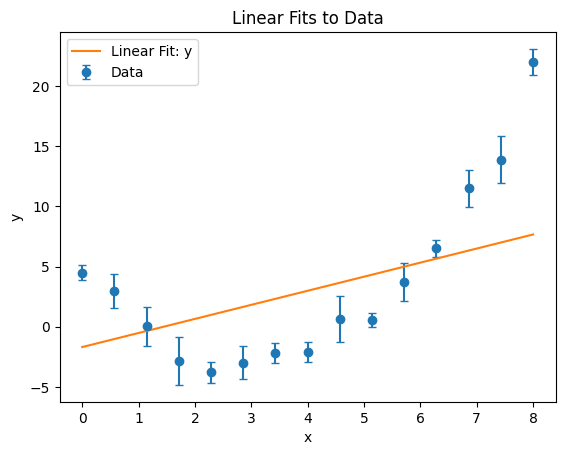

Parameters are [-1.68814608  1.16870947] with uncertainties of [2.79775315 0.61872312]
 qhi squire is 34.898610961320315


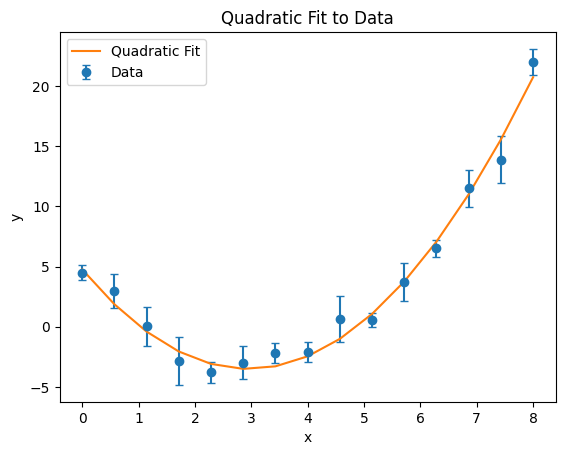

Parameters are [ 4.75577295 -5.60312899  0.94983992] with uncertainties of [0.46101871 0.27610564 0.03681489]
 qhi squire is 0.669481511096555


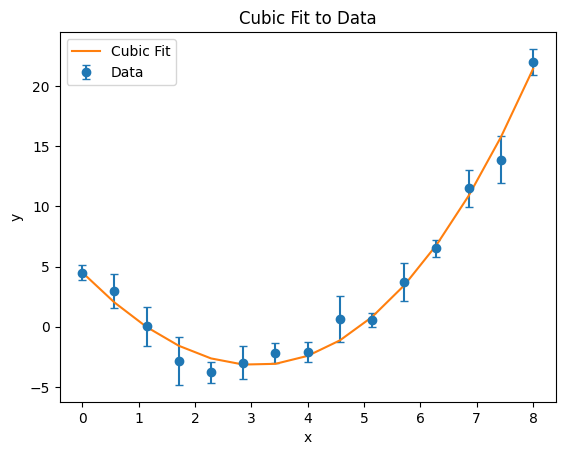

Parameters are [ 4.51294774 -4.74293252  0.64759163  0.0261743 ] with uncertainties of [0.4614101  0.60481697 0.19491644 0.01660939]
 qhi squire is 0.5958282898820532


In [9]:
data = np.loadtxt('w4bdata.txt', skiprows=1)
x_data, y_data, sigma = data[:, 0], data[:, 1], data[:, 2]

popt_lin, pcov_lin = curve_fit(linear, x_data, y_data, sigma=sigma)
popt_quad, pcov_quad = curve_fit(quadratic, x_data, y_data, sigma=sigma)
popt_cubic, pcov_cubic = curve_fit(cubic, x_data, y_data, sigma=sigma)

perr_lin = np.sqrt(np.diag(pcov_lin))
perr_quad = np.sqrt(np.diag(pcov_quad))
perr_cubic = np.sqrt(np.diag(pcov_cubic))

x_fit = np.linspace(min(x_data), max(x_data), len(x_data))

y_fit_lin = linear(x_fit, *popt_lin)
y_fit_quad = quadratic(x_fit, *popt_quad)
y_fit_cubic = cubic(x_fit, *popt_cubic)

dof = len(x_data) - (1 + 1)
residuals = (y_data - y_fit_lin) / sigma
chi2 = np.sum(residuals**2)
redchi2lin = chi2/dof

dof = len(x_data) - (2 + 1)
residuals = (y_data - y_fit_quad) / sigma
chi2 = np.sum(residuals**2)
redchi2quad = chi2/dof

dof = len(x_data) - (3 + 1)
residuals = (y_data - y_fit_cubic) / sigma
chi2 = np.sum(residuals**2)
redchi2cubic = chi2/dof

plt.errorbar(x_data, y_data, yerr=sigma, fmt='o', label='Data', capsize=3)
plt.plot(x_fit, y_fit_lin, label=f'Linear Fit: y')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Fits to Data')
plt.show()
print(f"Parameters are {popt_lin} with uncertainties of {perr_lin}")
print(f" qhi squire is {redchi2lin}")
plt.errorbar(x_data, y_data, yerr=sigma, fmt='o', label='Data', capsize=3)
plt.plot(x_fit, y_fit_quad, label='Quadratic Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Quadratic Fit to Data')
plt.show()
print(f"Parameters are {popt_quad} with uncertainties of {perr_quad}")
print(f" qhi squire is {redchi2quad}")
plt.errorbar(x_data, y_data, yerr=sigma, fmt='o', label='Data', capsize=3)
plt.plot(x_fit, y_fit_cubic, label='Cubic Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Cubic Fit to Data')
plt.show()
print(f"Parameters are {popt_cubic} with uncertainties of {perr_cubic}")
print(f" qhi squire is {redchi2cubic}")

**5. Plot residuals.**

(5 points) This continues Activity 4 and should
use the same data file. Make a figure with two subplots, one showing
the data and model as above, and the second showing the residuals
(difference between each data point and the model, along with error
bars).

**6. More polynomial fits to data**

(10 points) Fit the data in the file `data2.txt` to polynomials of various orders, and use the reduced chisquared results to decide what model (what order polynomial) is justified for fitting this data. Once again, use the function `scipy.optimize.curve_fit()` as described in the section labeled “Nonlinear least-squares fitting” in the handout **Fitting models to data**. Output the fitting parameters along with their uncertainties.

**7. Fit to data with unknown uncertainties**

(5 points) The file `data3.txt` has only two columns (x and y, but not yerr).If you have data with no uncertainties given, you can assume the $\sigma_j$  values are all equal to 1. You can either create an array `sigma` of the same length as the x and y arrays, or modify your program to assume $\sigma_j = 1$. Either way, fit the data to polynomials of various orders and decide what order
polynomial is justified as a model for the data. Plot the $x_j, y_j$ data as points or symbols without error bars. Output the fitting parameters along with their uncertainties.

**8. Fitting data to a sine wave**

(10 points) Read in the data from the file `wavedata.txt` and plot it. Based on the plot, decide on a likely model for the data. Decide on how many parameters will be needed; define the model fit function, and write a program to fit your model to the data. Show both model and data on the same plot.

[2.88937058 1.98500064 0.70163983 3.01750919]


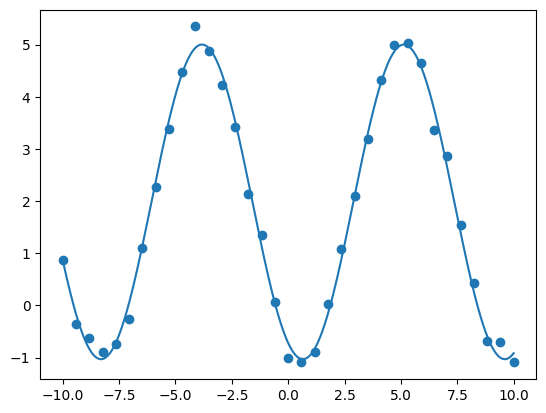

In [ ]:
wavedata = np.loadtxt("wavedata.txt", skiprows = 1)
x = wavedata[:, 0]
y = wavedata[:, 1]
guess = [1,1,1,1]
def wave(x, xshift, yshift, frequency, amplitude):
    x = np.asarray(x)
    return(amplitude * np.sin(frequency * (x - xshift)) + yshift)
popt, pcov = curve_fit(wave, x, y, p0 = guess)
xfit = np.linspace(-10, 10, 500)
yfit = wave(xfit, *popt)
plt.scatter(x, y)
plt.plot(xfit, yfit)
print(f"{popt}")


**9. The Madelung constant of an ionic solid** *(15 points)*

In an ionic crystal, the electrostatic energy experienced by a single ion is proportional to the Madelung constant, which is a geometrical quantity that depends on the structure of the crystal lattice.  In this problem, you will calculate the Madelung constant for a salt crystal, NaCl, where the alternating sodium and chlorine atoms sit equally spaced on a cubic grid (i.e. form a simple cubic lattice, see image below). The sodium ions are positive, and the chlorine ions are negative. Let $a$ be the lattice spacing, the separation between neighboring ions. Let $(i,j,k)$ be indices referring to the $(x,y,z)$ coordinates of each ion in crystal. The energy of an ion at the origin is then given by:
$$
V(i,j,k) =  C{(-1)^{i + j + k}\over\sqrt{i^2+j^2+k^2}},
$$
where $C$ is a constant inversely proportional to $a$ ($C = {e\over{(4\pi \epsilon_0 a)}}$).

The sum of this quantity for a cubical box centered around the origin is defined as the Madelung constant:
$$
M = \sum_{\substack{i,j,k=-L\\ \textrm{But not }i=j=k=0!}}^L
                   \hspace{-0.5em} {(-1)^{i + j + k}\over\sqrt{i^2+j^2+k^2}}
$$
You will do this for a lattice of finite size $L$, in which all three coordinates go from $-L$ to $L$. As stated in the summation symbol, avoid the origin $i = j = k = 0$ to avoid dividing by zero. Note also that in calculating the Madelung constant, you ignore the dimensional prefactor $C = \frac{e}{4\pi\epsilon_0 a}$.

In [ ]:
""""from google.colab import files
_ = files.upload()"""

'"from google.colab import files\n_ = files.upload()'

In [ ]:
def medlung(L):
    sum = 0
    medlunglist = np.arange(-L, L+1)
    for i in medlunglist:
        for j in medlunglist:
            for k in medlunglist:
                if i == 0 and j == 0 and k == 0:
                    continue
                else:
                    sum += (-1)**(np.abs(i+j+k)) / np.sqrt(i**2 + j**2 + k**2)
    return(float(sum))
medlung(10)

-1.6925789282594415

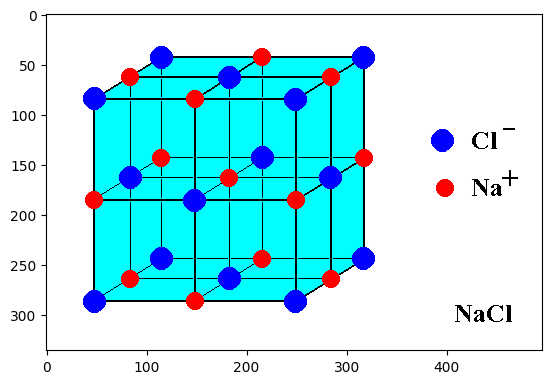

In [ ]:
import matplotlib.pyplot as plt
nacl = plt.imread('nacl.gif')
plt.imshow(nacl)
plt.show()

**10. Madelung constant: finite size effects**

(5 points) Choose a set of increasing L values, and use your previous program to plot how the Madelung constant changes as a function of lattice size $L$.

**11. 1D Random Walk in a restricted space**

In class, we discussed the unrestricted random walk in one dimension with `N` steps, and discussed repeating this walk `Ntrials` times.

Write code to carry out a **restricted** one dimensional random walk with the following rules:
- The walker starts at the origin, $x = 0$.
- The limits of the walk are $x = -50$ to $x = +50$. This means that if the walker position $x <= -50$, you always have to step to the right, i.e. add 1 to $x$. Alternatively, if the walker position $x >= +50$, you always have to go 1 step to the left, i.e. subtract 1 from $x$. If neither of these conditions are met, you will randomly add 1 or subtract 1. Keep track of the final position $x$ of the walker after $N$ steps.

a. *(10 points)* Carry out Ntrials = 1000 for $N$ = 100 and then 10,000 steps. In each case, find the mean $<x>$ and root mean squared displacement $(\Delta x)^2 = <x^2> - <x>^2$. How do these measures vary with $N$?

b. *(5 points)* Generate a histogram of the final positions of the walker for each N value. What is the shape of this distribution?



Steps = 100, Trials = 1000
mean: -0.226
rms: 10.058429300840166


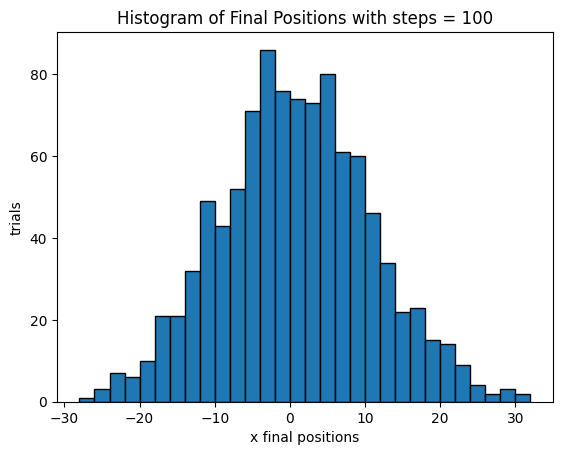

Steps = 10000, Trials = 1000
mean: -1.668
rms: 29.43453753671017


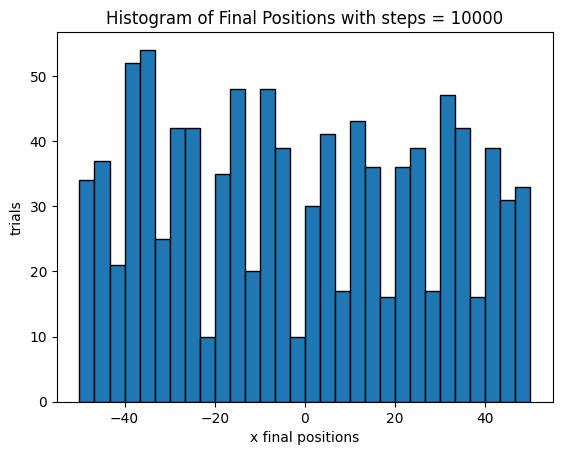

In [ ]:
rng = np.random.default_rng()
def randomwalk(N):
    x = 0  
    walk = [x]
    for step in range(N):
        if x == 50: 
            x -= 1
        elif x == -50: 
            x += 1
        else:
            x += rng.choice([-1, 1]) 
        walk.append(x)
    return walk

def randomplot(N, Ntrials):
    final_positions = []

    for trial in range(Ntrials):
        walk = randomwalk(N)
        final_positions.append(walk[-1])
    final_positions = np.array(final_positions)

    mean = np.mean(final_positions)
    rms = (np.sqrt(np.mean(np.square(final_positions))))

    print(f"Steps = {N}, Trials = {Ntrials}")
    print(f"mean: {mean}")
    print(f"rms: {rms}")

    plt.hist(final_positions, bins=30, edgecolor="black")
    plt.xlabel("x final positions")
    plt.ylabel("trials")
    plt.title(f"Histogram of Final Positions with steps = {N}")
    plt.show()

randomplot(100, 1000)
randomplot(10000, 1000)


**12.Unrestricted 1D Random Walk with steps drawn from a Gaussian distribution**

Write code to carry out an unrestricted random walk of $N$ steps in 1 dimension where each step is drawn from a Gaussian distribution centered at 0 and with width 1, i.e. use `rng.normal(0, 1, ...)`. Each distinct walk begins at the origin $x = 0$. As in the previous problem, repeat the $N$ step walk `Ntrials` times, and keep track of the final position $x$ of the walker after each trial.  *(Hint: you may be able to find this final position more easily if you generate $N$ random numbers at once)*.

a. *(5 points)* Carry out Ntrials = 1000 for $N$ = 100 and then 10,000 steps. In each case, find the mean $<x>$ and root mean squared displacement $(\Delta x)^2 = <x^2> - <x>^2$. How do these measures vary with $N$?

b. *(5 points)* Generate a histogram of the final positions of the walker for each N value. What is the shape of this distribution? You may need to increase the number of bins to see the shape clearly.

Steps = 100, Trials = 1000
mean: 0.24483093410890194
rms: 9.961909973899587


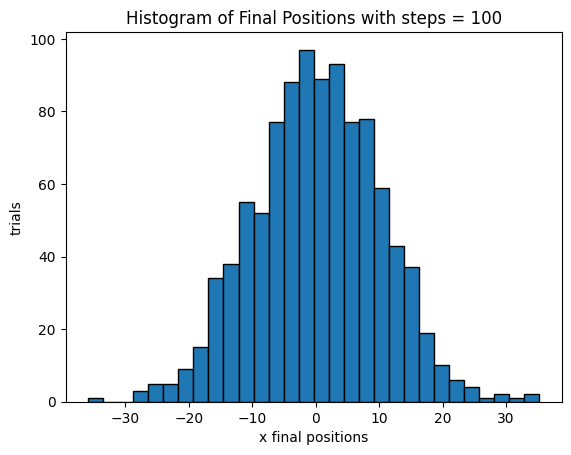

Steps = 10000, Trials = 1000
mean: 0.631019670129763
rms: 104.55718328242001


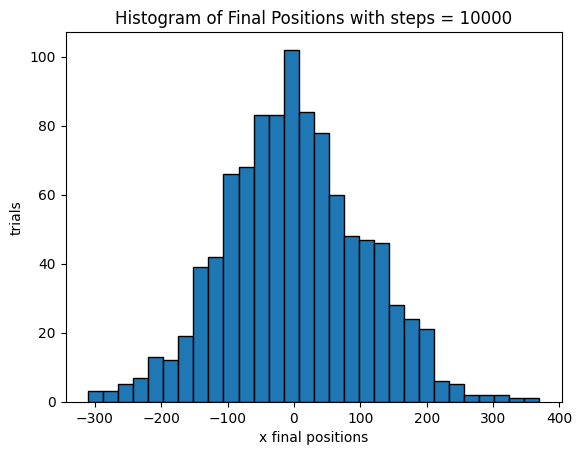

In [ ]:
rng = np.random.default_rng()
def randomwalk(N):
    x = 0  
    walk = [x]
    step = rng.normal(0,1,N)
    walk = np.cumsum(step)
    walk = np.insert(walk, 0, 0)
    return walk

def randomplot(N, Ntrials):
    final_positions = []

    for trial in range(Ntrials):
        walk = randomwalk(N)
        final_positions.append(walk[-1])
    final_positions = np.array(final_positions)

    mean = np.mean(final_positions)
    rms = (np.sqrt(np.mean(np.square(final_positions))))

    print(f"Steps = {N}, Trials = {Ntrials}")
    print(f"mean: {mean}")
    print(f"rms: {rms}")

    plt.hist(final_positions, bins=30, edgecolor="black")
    plt.xlabel("x final positions")
    plt.ylabel("trials")
    plt.title(f"Histogram of Final Positions with steps = {N}")
    plt.show()

randomplot(100, 1000)
randomplot(10000, 1000)

**13.1D Random Walk with steps drawn from a Cauchy distribution** *(15 points)*

Write code to carry out an unrestricted random walk of $N$ steps in 1 dimension where each step is drawn from a Lorentzian or Cauchy distribution:  use `rng.standard_cauchy(N)`. Each distinct walk begins at the origin $x = 0$. As in the previous problem, repeat the $N$ step walk `Ntrials` times, and keep track of the final position $x$ of the walker after each trial.  Generate a histogram of the final positions of the walker for each $N$ value. How does the shape of this distribution compare with the Gaussian in the previous problem?

**Programming notes:** it will not be easy to see the shape of this distribition without cutomizing the locations of the bin edges in your histogram. Use the following commands:

`
edges = np.linspace(lower,upper,100)
`

`
plt.hist(xfinal,bins = edges, rwidth = 0.9)
`

where `lower` and `upper` are values you set so that you may suitably view the shape of the distribution.